<a href="https://colab.research.google.com/github/alexdiehl0/my-profile/blob/alexdiehl/Backtest/MUSDT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip -q install pandas openpyxl matplotlib numpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Binance --> Bitget

In [ ]:
from google.colab import files
uploaded = files.upload()
excel_path = list(uploaded.keys())[0]



Saving sample_market_data.xlsx to sample_market_data (1).xlsx


In [ ]:
 df = pd.read_excel(excel_path)

Spreads

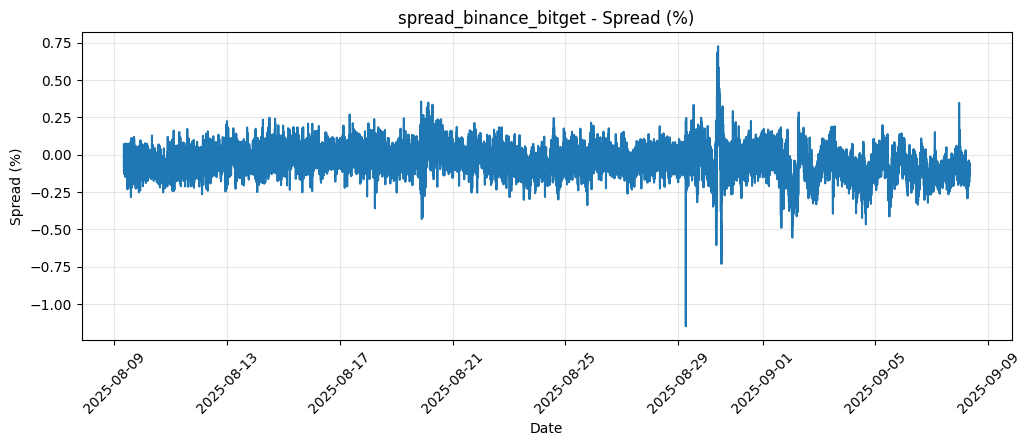

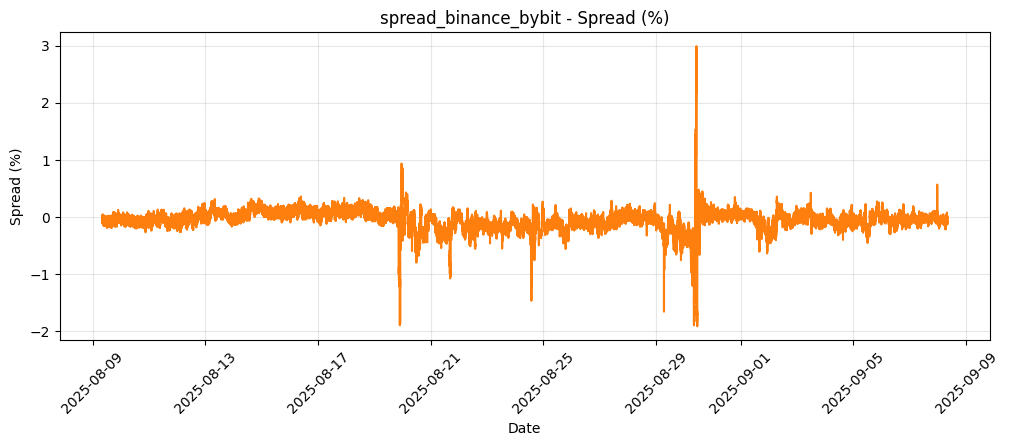

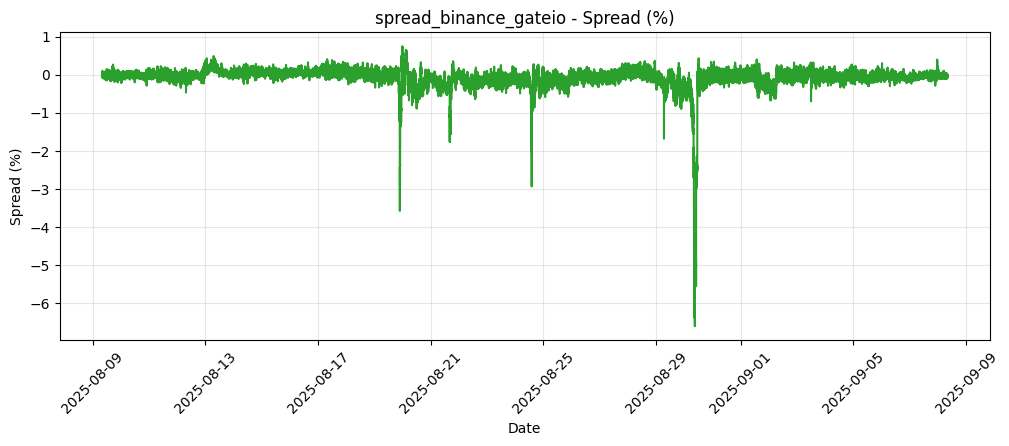

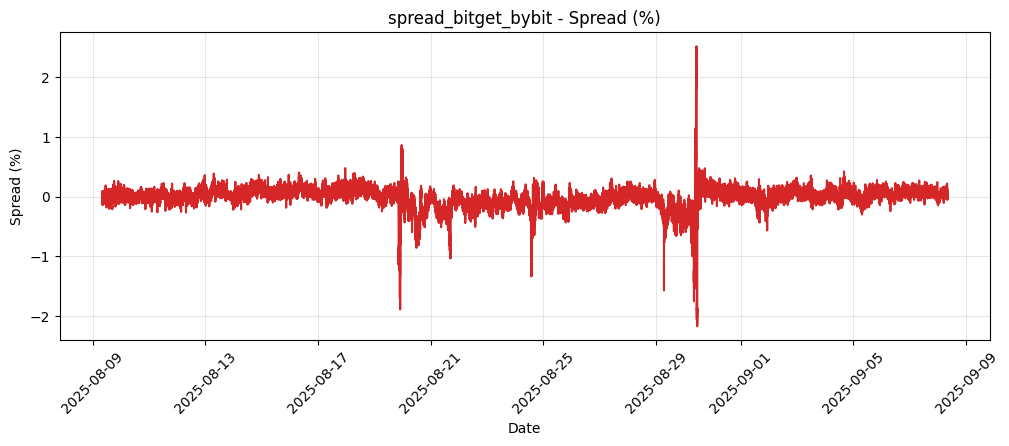

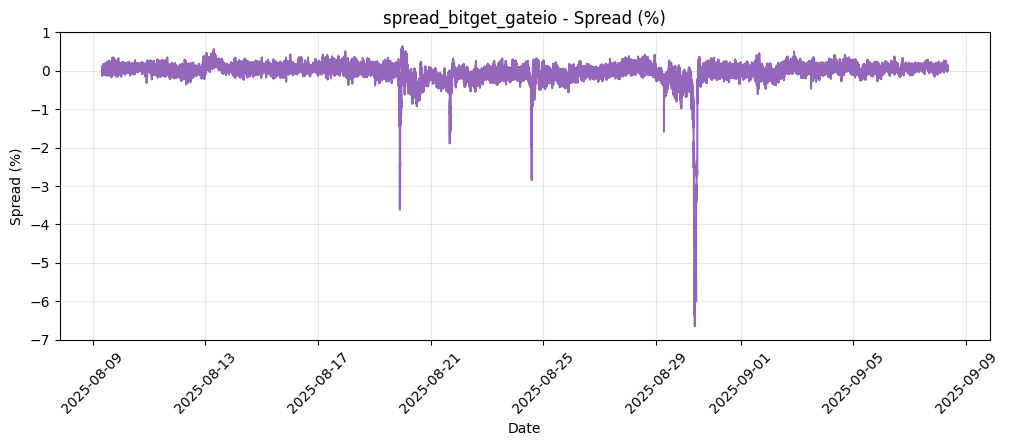

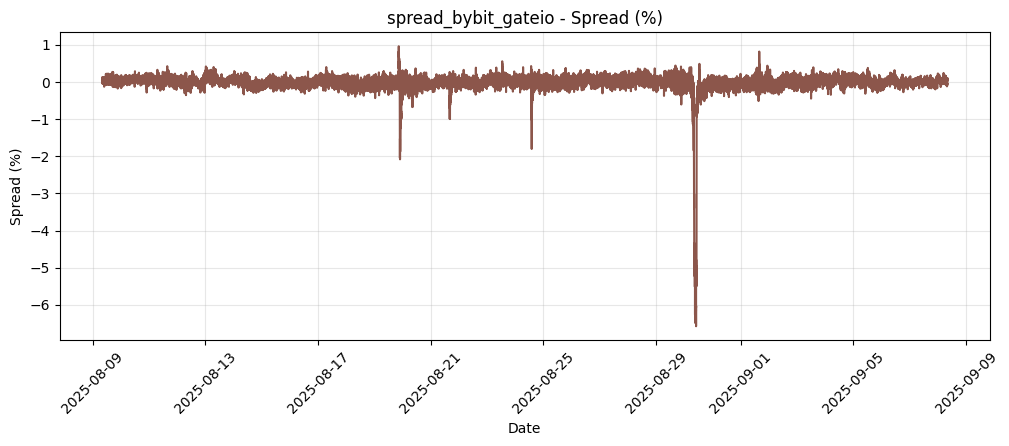

In [ ]:

# Spread absolu
price_cols = {
    "binance": "M/USDT:USDT+binance",
    "bitget":  "M/USDT:USDT+bitget",
    "bybit":   "M/USDT:USDT+bybit",
    "gateio":  "M/USDT:USDT+gateio"
}

def compute_spread(df, col1, col2):
    return df[col1] / df[col2] - 1

# Toutes les combinaisons 2 à 2
from itertools import combinations

for ex1, ex2 in combinations(price_cols.keys(), 2):
    colname = f"spread_{ex1}_{ex2}"
    df[colname] = compute_spread(df, price_cols[ex1], price_cols[ex2])

spread_cols = [c for c in df.columns if c.startswith("spread_")]

df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

for i, col in enumerate(spread_cols):
    plt.figure(figsize=(12,4))
    plt.plot(df["timestamp"], df[col]*100, color="C"+str(i))
    plt.title(f"{col} - Spread (%)")
    plt.xlabel("Date")
    plt.ylabel("Spread (%)")
    plt.grid(True, alpha=0.3)

    # 👉 formater les dates
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.xticks(rotation=45)

    plt.show()


Binance --> Bitget

,entry_time,exit_time,position,entry_spread,exit_spread,entry_price_binance,entry_price_bitget,exit_price_binance,exit_price_bitget,pnl_pct,cum_pnl_pct
0,2025-08-10 08:00:00,2025-08-10 13:33:00,short_spread,0.011%,-0.196%,0.4661,0.46605,0.4476,0.44848,0.047%,0.047%
1,2025-08-10 13:39:00,2025-08-10 16:14:00,short_spread,0.07%,-0.155%,0.4451,0.44479,0.4456,0.44629,0.064%,0.111%
2,2025-08-10 16:17:00,2025-08-10 21:18:00,long_spread,-0.181%,0.0%,0.4458,0.44661,0.4483,0.44830,0.021%,0.133%
3,2025-08-10 21:21:00,2025-08-11 00:13:00,short_spread,0.022%,-0.174%,0.4499,0.44980,0.4581,0.45890,0.037%,0.169%
4,2025-08-11 00:35:00,2025-08-11 03:05:00,short_spread,0.037%,-0.233%,0.4633,0.46313,0.4658,0.46689,0.11%,0.279%
...,...,...,...,...,...,...,...,...,...,...,...
137,2025-09-05 16:01:00,2025-09-06 03:24:00,short_spread,0.078%,-0.246%,1.5880,1.58676,1.6254,1.62941,0.164%,10.976%
138,2025-09-06 10:59:00,2025-09-06 15:03:00,long_spread,-0.235%,0.031%,1.7000,1.70400,1.7159,1.71536,0.106%,11.082%
139,2025-09-06 15:06:00,2025-09-06 17:26:00,short_spread,0.109%,-0.209%,1.7156,1.71373,1.7626,1.76629,0.158%,11.24%
140,2025-09-06 17:34:00,2025-09-07 02:35:00,long_spread,-0.209%,-0.024%,1.7558,1.75947,1.8698,1.87024,0.025%,11.265%


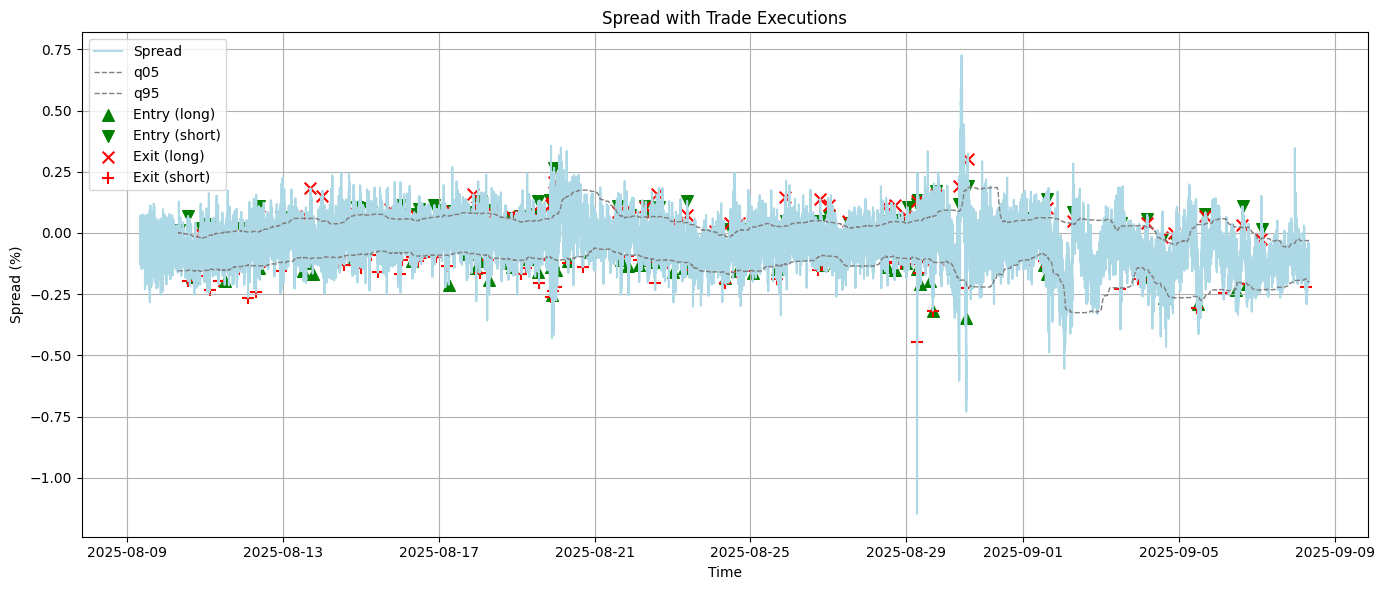

Average PnL per trade: 0.0798%


In [ ]:
# --- Prep ---
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["spread"] = (df[binance_col] / df[bitget_col] - 1) * 100  # in %
window_spread = 1
if window_spread > 1:
    df["spread"] = df["spread"].rolling(window_spread, min_periods=window_spread).mean()

fee_rate = 0.00040 # 0.025% per order
window = 1391    # 1 day of minutes
col = "spread"

# --- Outlier filter (10min rolling 3σ replacement) ---
df["mean_10m"] = df[col].rolling(10, min_periods=10).mean()
df["std_10m"]  = df[col].rolling(10, min_periods=10).std()
upper = df["mean_10m"] + 3 * df["std_10m"]
lower = df["mean_10m"] - 3 * df["std_10m"]


# Replace outliers with rolling mean
df["spread_clean"] = df[col].where(
    (df[col] <= upper) & (df[col] >= lower),
    df["mean_10m"]
)

# Rolling quantiles (lagged to avoid lookahead)
df["q95"] = df[col].rolling(window, min_periods=window).quantile(0.8986707143283659).shift(1)
df["q05"] = df[col].rolling(window, min_periods=window).quantile(0.056530107281601544).shift(1)
window = 1391
# Next-bar values (compute ONCE, before the loop)
df["spread_next"] = df[col].shift(-1)
df["q95_next"]    = df["q95"].shift(-1)
df["q05_next"]    = df["q05"].shift(-1)

trades = []
in_position = False
position = None

for i, row in df.iterrows():
    # skip until rolling quantiles exist
    if pd.isna(row["q95"]) or pd.isna(row["q05"]):
        continue

    spread = row[col]
    binance_price = row[binance_col]
    bitget_price  = row[bitget_col]

    # --- Entry conditions with 1-minute persistence ---
    if (not in_position
        and spread > row["q95"]
        and not pd.isna(row["spread_next"]) and not pd.isna(row["q95_next"])
        and row["spread_next"] > row["q95_next"]):
        # SHORT SPREAD (expensive -> cheap expectation)
        entry_time = row["timestamp"]
        entry_spread = spread
        entry_price_binance = binance_price
        entry_price_bitget  = bitget_price
        position = "short_spread"
        in_position = True

    elif (not in_position
          and spread < row["q05"]
          and not pd.isna(row["spread_next"]) and not pd.isna(row["q05_next"])
          and row["spread_next"] < row["q05_next"]):
        # LONG SPREAD (cheap -> expensive expectation)
        entry_time = row["timestamp"]
        entry_spread = spread
        entry_price_binance = binance_price
        entry_price_bitget  = bitget_price
        position = "long_spread"
        in_position = True

    # --- Exit at opposite quantile with 1-minute persistence ---
    elif in_position:
        exit_now = False
        has_next = (not pd.isna(row["spread_next"])) and (not pd.isna(row["q95_next"])) and (not pd.isna(row["q05_next"]))

        if position == "short_spread":
            # exit if BOTH current and next minute are <= q05
            if has_next and (spread <= row["q05"]) and (row["spread_next"] <= row["q05_next"]):
                exit_now = True
        elif position == "long_spread":
            # exit if BOTH current and next minute are >= q95
            if has_next and (spread >= row["q95"]) and (row["spread_next"] >= row["q95_next"]):
                exit_now = True

        # Safety: if no next bar (end of data), allow exit on current-bar signal
        if not has_next:
            if (position == "short_spread" and spread <= row["q05"]) or \
               (position == "long_spread"  and spread >= row["q95"]):
                exit_now = True

        if exit_now:
            exit_time = row["timestamp"]
            exit_spread = spread
            exit_price_binance = binance_price
            exit_price_bitget  = bitget_price

            raw_pnl = (entry_spread - exit_spread) if position == "short_spread" else (exit_spread - entry_spread)

            # costs per trade (4 legs total)
            fees = 4 * fee_rate * 100
            slippage_rate = 0.000  # 0.02% per leg (update comment!)
            slippage_cost = 4 * slippage_rate * 100

            pnl_pct = raw_pnl - fees - slippage_cost

            trades.append({
                "entry_time": entry_time,
                "exit_time": exit_time,
                "position": position,
                "entry_spread": entry_spread,
                "exit_spread": exit_spread,
                "entry_price_binance": entry_price_binance,
                "entry_price_bitget": entry_price_bitget,
                "exit_price_binance": exit_price_binance,
                "exit_price_bitget": exit_price_bitget,
                "pnl_pct": pnl_pct
            })

            in_position = False
            position = None



# --- Results table ---
trades_df = pd.DataFrame(trades)
if not trades_df.empty:
    n_trades = len(trades_df)

    # add total fees & slippage columns
    trades_df["fees_pct"] = 4 * fee_rate * 100
    trades_df["slippage_pct"] = 4 * slippage_rate * 100

    trades_df["cum_fees_pct"] = trades_df["fees_pct"].cumsum()
    trades_df["cum_slippage_pct"] = trades_df["slippage_pct"].cumsum()

    trades_df["cum_pnl_pct"] = trades_df["pnl_pct"].cumsum()


    cols = [
        "entry_time", "exit_time", "position",
        "entry_spread", "exit_spread",
        "entry_price_binance", "entry_price_bitget",
        "exit_price_binance", "exit_price_bitget",
        "pnl_pct", "cum_pnl_pct"
    ]
    trades_clean = trades_df[cols].copy()
    trades_clean["entry_spread"] = trades_clean["entry_spread"].round(3).astype(str) + "%"
    trades_clean["exit_spread"]  = trades_clean["exit_spread"].round(3).astype(str) + "%"
    trades_clean["pnl_pct"]      = trades_clean["pnl_pct"].round(3).astype(str) + "%"
    trades_clean["cum_pnl_pct"]  = trades_clean["cum_pnl_pct"].round(3).astype(str) + "%"

    from IPython.display import display
    display(trades_clean)
else:
    print("No trades were executed under the current logic.")


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Ensure datetime index ---
df = df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Optional: choose a date window (comment out to show all)
start, end = None, None   # e.g. "2025-08-11 11:00", "2025-08-12 00:00"
if start and end:
    mask = (df["timestamp"] >= start) & (df["timestamp"] <= end)
    df_plot = df.loc[mask].copy()
else:
    df_plot = df.copy()

# --- Prepare trades (handle % strings gracefully) ---
trades_plot = trades_df.copy()

def to_float_series(s):
    # If dtype is object (e.g., "0.123%"), strip '%' else keep as float
    if pd.api.types.is_object_dtype(s):
        return s.astype(str).str.replace('%','', regex=False).astype(float)
    return s.astype(float)

for colname in ["entry_spread", "exit_spread"]:
    if colname in trades_plot.columns:
        trades_plot[colname] = to_float_series(trades_plot[colname])

# If you stored spreads in percent units, they’re already on the same scale as df["spread"].
# If df["spread"] is in decimal (e.g., 0.001 vs 0.1%), convert:
# df_plot["spread"] = df_plot["spread"] * 100

# --- Split trades by side for nicer markers ---
long_trades  = trades_plot[trades_plot["position"] == "long_spread"]
short_trades = trades_plot[trades_plot["position"] == "short_spread"]

# --- Plot ---
plt.figure(figsize=(14,6))

# Spread (light blue line)
plt.plot(df_plot["timestamp"], df_plot["spread"], label="Spread", color="lightblue")

# Bands if present
if "q05" in df_plot.columns and "q95" in df_plot.columns:
    plt.plot(df_plot["timestamp"], df_plot["q05"], linestyle="--", linewidth=1, color="gray", label="q05")
    plt.plot(df_plot["timestamp"], df_plot["q95"], linestyle="--", linewidth=1, color="gray", label="q95")

# Entries = green triangles
if not long_trades.empty:
    plt.scatter(long_trades["entry_time"], long_trades["entry_spread"],
                marker="^", s=70, color="green", label="Entry (long)")
if not short_trades.empty:
    plt.scatter(short_trades["entry_time"], short_trades["entry_spread"],
                marker="v", s=70, color="green", label="Entry (short)")

# Exits = red markers
if not long_trades.empty:
    plt.scatter(long_trades["exit_time"], long_trades["exit_spread"],
                marker="x", s=70, color="red", label="Exit (long)")
if not short_trades.empty:
    plt.scatter(short_trades["exit_time"], short_trades["exit_spread"],
                marker="+", s=70, color="red", label="Exit (short)")

plt.title("Spread with Trade Executions")
plt.xlabel("Time")
plt.ylabel("Spread (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Remove % sign and convert to float
trades_clean["pnl_pct_num"] = trades_clean["pnl_pct"].str.replace('%', '', regex=False).astype(float)

# Compute average
avg_pnl = trades_clean["pnl_pct_num"].mean()
print(f"Average PnL per trade: {avg_pnl:.4f}%")

=== Trade Summary ===
Trades        : 142
Wins / Losses : 137 / 5  (Win rate: 96.5%)
Avg gross PnL : 0.240%   | Fees/trade: 0.100%
Avg net PnL   : 0.080%  (median: 0.064%)
Beat 2× fees  : 64.8% of trades
Beat 3× fees  : 16.9% of trades
Direction     : long=59, short=83
Holding time  : mean=0 days 04:19:29.577464788, median=0 days 02:15:00, max=1 days 13:36:00

=== Weekly PnL ===


,weekly_net_pnl_pct,cum_net_pnl_pct
exit_time,,
2025-08-10 00:00:00,0.133%,0.133%
2025-08-17 00:00:00,2.136%,2.269%
2025-08-24 00:00:00,3.820%,6.089%
2025-08-31 00:00:00,3.476%,9.565%
2025-09-07 00:00:00,1.700%,11.265%
2025-09-14 00:00:00,0.074%,11.339%



=== Weekly Contribution (%) ===


,share_of_total_%
exit_time,
2025-08-10 00:00:00,1.2%
2025-08-17 00:00:00,18.8%
2025-08-24 00:00:00,33.7%
2025-08-31 00:00:00,30.7%
2025-09-07 00:00:00,15.0%
2025-09-14 00:00:00,0.7%


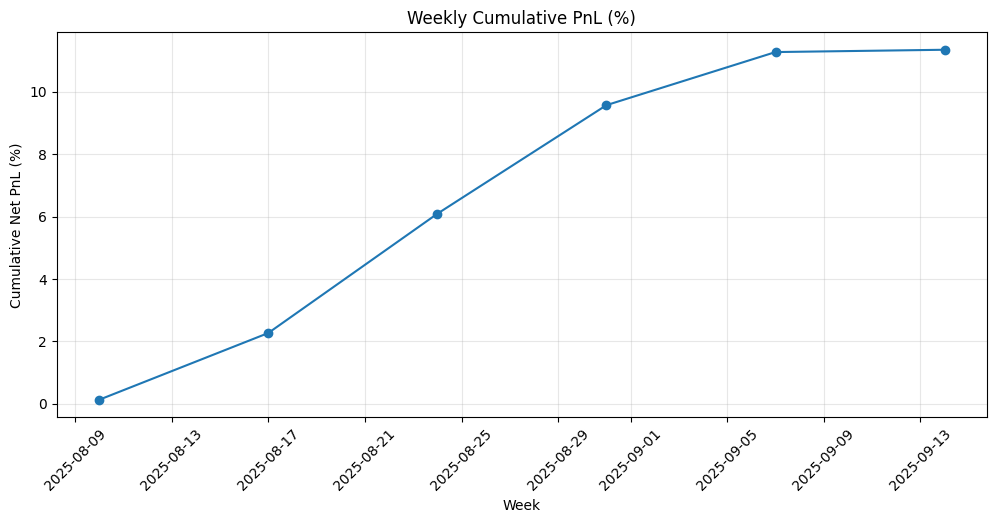

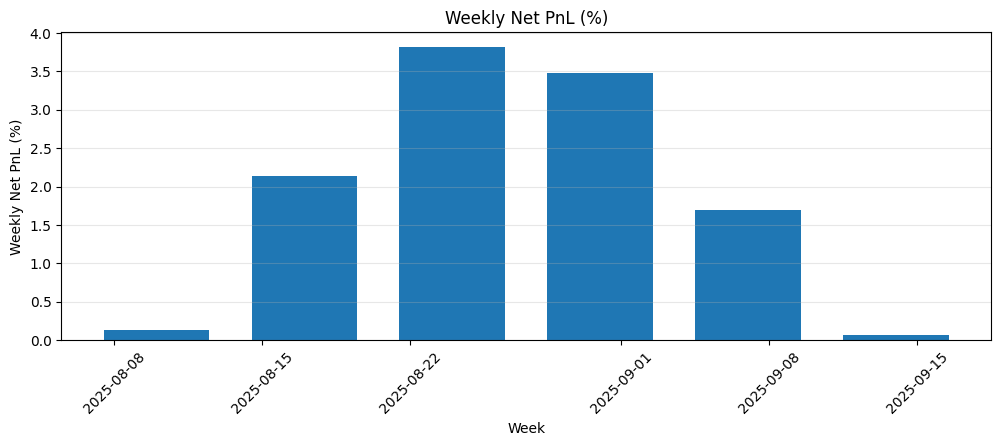

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Safety: bail out if no trades
if trades_df.empty:
    print("No trades in trades_df.")
else:
    # Ensure datetimes
    trades_df["entry_time"] = pd.to_datetime(trades_df["entry_time"])
    trades_df["exit_time"]  = pd.to_datetime(trades_df["exit_time"])

    # --- Recompute gross PnL (before fees) and holding time
    fee_rate = 0.00025   # 0.025% per order
    fees_pct = 4 * fee_rate * 100  # % per roundtrip

    # raw move of the spread (in percentage points)
    raw_move = np.where(
        trades_df["position"].eq("short_spread"),
        trades_df["entry_spread"] - trades_df["exit_spread"],
        trades_df["exit_spread"] - trades_df["entry_spread"]
    )
    trades_df["gross_pnl_pct"] = raw_move          # before fees
    trades_df["net_pnl_pct"]   = trades_df["pnl_pct"]  # after fees (already computed earlier)
    trades_df["fees_pct"]      = fees_pct
    trades_df["holding_time"]  = trades_df["exit_time"] - trades_df["entry_time"]

    # --- 1) Win/Loss counts & win rate
    trades_df["win"] = trades_df["net_pnl_pct"] > 0
    n_trades   = len(trades_df)
    n_wins     = int(trades_df["win"].sum())
    n_losses   = n_trades - n_wins
    win_rate   = 100 * n_wins / n_trades if n_trades else 0

    # --- 2) Average PnL per trade vs fees
    avg_gross  = trades_df["gross_pnl_pct"].mean()
    avg_net    = trades_df["net_pnl_pct"].mean()
    med_net    = trades_df["net_pnl_pct"].median()
    # how many trades beat 2× and 3× fees?
    beat_2x    = (trades_df["gross_pnl_pct"] > 2*fees_pct).mean() * 100
    beat_3x    = (trades_df["gross_pnl_pct"] > 3*fees_pct).mean() * 100

    # --- 3) Long vs Short balance
    dir_counts = trades_df["position"].value_counts()
    long_count  = int(dir_counts.get("long_spread", 0))
    short_count = int(dir_counts.get("short_spread", 0))

    # --- 4) Stability across time: weekly stats
    # Use exit_time to book PnL to the week it was realized
    trades_df = trades_df.sort_values("exit_time").copy()
    weekly = (trades_df
              .set_index("exit_time")["net_pnl_pct"]
              .resample("W")  # weekly on Sundays by default
              .sum()
              .to_frame("weekly_net_pnl_pct"))
    weekly["cum_net_pnl_pct"] = weekly["weekly_net_pnl_pct"].cumsum()

    # dominance check: contribution share per week
    contrib = (weekly["weekly_net_pnl_pct"]
               / weekly["weekly_net_pnl_pct"].sum()
               * 100).fillna(0)

    # --- Print a compact summary
    print("=== Trade Summary ===")
    print(f"Trades        : {n_trades}")
    print(f"Wins / Losses : {n_wins} / {n_losses}  (Win rate: {win_rate:.1f}%)")
    print(f"Avg gross PnL : {avg_gross:.3f}%   | Fees/trade: {fees_pct:.3f}%")
    print(f"Avg net PnL   : {avg_net:.3f}%  (median: {med_net:.3f}%)")
    print(f"Beat 2× fees  : {beat_2x:.1f}% of trades")
    print(f"Beat 3× fees  : {beat_3x:.1f}% of trades")
    print(f"Direction     : long={long_count}, short={short_count}")

    ht = trades_df["holding_time"]
    print(f"Holding time  : mean={ht.mean()}, median={ht.median()}, max={ht.max()}")

    print("\n=== Weekly PnL ===")
    display(weekly.style.format({"weekly_net_pnl_pct": "{:.3f}%", "cum_net_pnl_pct": "{:.3f}%"}))

    print("\n=== Weekly Contribution (%) ===")
    display(contrib.to_frame("share_of_total_%").style.format({"share_of_total_%": "{:.1f}%"}))

    # --- 5) Weekly cumulative PnL curve
    plt.figure(figsize=(12,5))
    plt.plot(weekly.index, weekly["cum_net_pnl_pct"], marker="o")
    plt.title("Weekly Cumulative PnL (%)")
    plt.xlabel("Week")
    plt.ylabel("Cumulative Net PnL (%)")
    plt.grid(True, alpha=0.3)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.xticks(rotation=45)
    plt.show()

    # Optional: weekly bars to see if 1–2 weeks dominate
    plt.figure(figsize=(12,4))
    plt.bar(weekly.index, weekly["weekly_net_pnl_pct"], width=5)  # width in days
    plt.title("Weekly Net PnL (%)")
    plt.xlabel("Week")
    plt.ylabel("Weekly Net PnL (%)")
    plt.grid(True, axis="y", alpha=0.3)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.xticks(rotation=45)
    plt.show()


**Optimization**

In [ ]:
import pandas as pd

def run_backtest(df, q_high=0.95, q_low=0.05, window=1440,
                 fee_rate=0.00025, slippage_rate=0.0002):
    """
    Backtest spread strategy with quantile bands.

    Args:
        df (DataFrame): must contain 'timestamp', binance_col, bitget_col
        q_high (float): upper quantile threshold (e.g., 0.95)
        q_low (float): lower quantile threshold (e.g., 0.05)
        window (int): rolling window length in minutes
        fee_rate (float): trading fee per leg
        slippage_rate (float): slippage per leg

    Returns:
        float: cumulative PnL percentage
    """

    df = df.copy()
    df["spread"] = (df[binance_col] / df[bitget_col] - 1) * 100

    # --- Outlier filter (10min rolling 3σ replacement) ---
    df["mean_10m"] = df["spread"].rolling(10, min_periods=10).mean()
    df["std_10m"]  = df["spread"].rolling(10, min_periods=10).std()
    upper = df["mean_10m"] + 3 * df["std_10m"]
    lower = df["mean_10m"] - 3 * df["std_10m"]
    df["spread_clean"] = df["spread"].where(
        (df["spread"] <= upper) & (df["spread"] >= lower),
        df["mean_10m"]
    )

    # --- Rolling quantiles (shift(1) = no lookahead) ---
    df["q_high"] = (
        df["spread_clean"].rolling(window, min_periods=window).quantile(q_high).shift(1)
    )
    df["q_low"] = (
        df["spread_clean"].rolling(window, min_periods=window).quantile(q_low).shift(1)
    )

    # Persistence check (1-bar ahead)
    df["spread_next"] = df["spread_clean"].shift(-1)
    df["q_high_next"] = df["q_high"].shift(-1)
    df["q_low_next"]  = df["q_low"].shift(-1)

    trades = []
    in_position = False
    position = None

    for i, row in df.iterrows():
        if pd.isna(row["q_high"]) or pd.isna(row["q_low"]):
            continue

        spread = row["spread_clean"]
        binance_price = row[binance_col]
        bitget_price  = row[bitget_col]

        # --- Entry ---
        if (not in_position
            and spread > row["q_high"]
            and not pd.isna(row["spread_next"])
            and row["spread_next"] > row["q_high_next"]):
            entry_time = row["timestamp"]
            entry_spread = spread
            entry_price_binance = binance_price
            entry_price_bitget  = bitget_price
            position = "short_spread"
            in_position = True

        elif (not in_position
              and spread < row["q_low"]
              and not pd.isna(row["spread_next"])
              and row["spread_next"] < row["q_low_next"]):
            entry_time = row["timestamp"]
            entry_spread = spread
            entry_price_binance = binance_price
            entry_price_bitget  = bitget_price
            position = "long_spread"
            in_position = True

        # --- Exit ---
        elif in_position:
            exit_now = False
            if position == "short_spread":
                if (spread <= row["q_low"]) and (row["spread_next"] <= row["q_low_next"]):
                    exit_now = True
            elif position == "long_spread":
                if (spread >= row["q_high"]) and (row["spread_next"] >= row["q_high_next"]):
                    exit_now = True

            if exit_now:
                exit_time = row["timestamp"]
                exit_spread = spread
                exit_price_binance = binance_price
                exit_price_bitget  = bitget_price

                raw_pnl = (entry_spread - exit_spread) if position == "short_spread" else (exit_spread - entry_spread)

                # Fees and slippage
                fees = 4 * fee_rate * 100
                slippage_cost = 4 * slippage_rate * 100
                pnl_pct = raw_pnl - fees - slippage_cost

                trades.append(pnl_pct)

                in_position = False
                position = None

    return sum(trades) if trades else 0.0


!pip install optuna
import optuna

def objective(trial):
    q_high = trial.suggest_uniform("q_high", 0.85, 0.99)
    q_low  = trial.suggest_uniform("q_low", 0.01, 0.15)
    window = trial.suggest_int("window", 60, 1440)  # 1h to 1d

    pnl = run_backtest(df, q_high=q_high, q_low=q_low, window=window)
    return pnl  # maximize PnL

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

print("Best params:", study.best_params)
print("Best PnL:", study.best_value)


# Optimization

In [ ]:
def run_backtest(df, exch1_col, exch2_col,
                 q_high=0.95, q_low=0.05, window=1440,
                 fee_rate=0.00025, slippage_rate=0.0002):
    """
    Backtest spread strategy between two exchanges using quantile bands.
    """
    df = df.copy()
    df["spread"] = (df[exch1_col] / df[exch2_col] - 1) * 100

    # --- Outlier filter (10min rolling 3σ replacement) ---
    df["mean_10m"] = df["spread"].rolling(10, min_periods=10).mean()
    df["std_10m"]  = df["spread"].rolling(10, min_periods=10).std()
    upper = df["mean_10m"] + 3 * df["std_10m"]
    lower = df["mean_10m"] - 3 * df["std_10m"]
    df["spread_clean"] = df["spread"].where(
        (df["spread"] <= upper) & (df["spread"] >= lower),
        df["mean_10m"]
    )

    # --- Rolling quantiles (shift(1) = no lookahead) ---
    df["q_high"] = df["spread_clean"].rolling(window, min_periods=window).quantile(q_high).shift(1)
    df["q_low"]  = df["spread_clean"].rolling(window, min_periods=window).quantile(q_low).shift(1)

    # Persistence check
    df["spread_next"] = df["spread_clean"].shift(-1)
    df["q_high_next"] = df["q_high"].shift(-1)
    df["q_low_next"]  = df["q_low"].shift(-1)

    trades = []
    in_position, position = False, None

    for i, row in df.iterrows():
        if pd.isna(row["q_high"]) or pd.isna(row["q_low"]):
            continue

        spread = row["spread_clean"]
        price1 = row[exch1_col]
        price2 = row[exch2_col]

        # --- Entry ---
        if (not in_position
            and spread > row["q_high"]
            and not pd.isna(row["spread_next"])
            and row["spread_next"] > row["q_high_next"]):
            entry_spread = spread
            position = "short_spread"
            in_position = True

        elif (not in_position
              and spread < row["q_low"]
              and not pd.isna(row["spread_next"])
              and row["spread_next"] < row["q_low_next"]):
            entry_spread = spread
            position = "long_spread"
            in_position = True

        # --- Exit ---
        elif in_position:
            exit_now = False
            if position == "short_spread":
                if (spread <= row["q_low"]) and (row["spread_next"] <= row["q_low_next"]):
                    exit_now = True
            elif position == "long_spread":
                if (spread >= row["q_high"]) and (row["spread_next"] >= row["q_high_next"]):
                    exit_now = True

            if exit_now:
                exit_spread = spread
                raw_pnl = (entry_spread - exit_spread) if position == "short_spread" else (exit_spread - entry_spread)

                # Costs
                fees = 4 * fee_rate * 100
                slippage_cost = 4 * slippage_rate * 100
                pnl_pct = raw_pnl - fees - slippage_cost
                trades.append(pnl_pct)

                in_position, position = False, None

    return sum(trades) if trades else 0.0


In [ ]:
import optuna

binance_col = "M/USDT:USDT+binance"
bybit_col   = "M/USDT:USDT+bybit"

def objective(trial):
    q_high = trial.suggest_uniform("q_high", 0.85, 0.99)
    q_low  = trial.suggest_uniform("q_low", 0.01, 0.15)
    window = trial.suggest_int("window", 60, 1440)  # 1h to 1d

    pnl = run_backtest(df, exch1_col=binance_col, exch2_col=bybit_col,
                       q_high=q_high, q_low=q_low, window=window)
    return pnl

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

print("Best params:", study.best_params)
print("Best PnL:", study.best_value)


[I 2025-09-11 08:50:55,289] A new study created in memory with name: no-name-64cceeb4-1fbd-4b31-892c-9522b2b312d2
/tmp/ipython-input-64221457.py:7: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  q_high = trial.suggest_uniform("q_high", 0.85, 0.99)
/tmp/ipython-input-64221457.py:8: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  q_low  = trial.suggest_uniform("q_low", 0.01, 0.15)
[I 2025-09-11 08:50:58,333] Trial 0 finished with value: 10.386500266170316 and parameters: {'q_high': 0.9834751116626371, 'q_low': 0.013266718308319485, 'window': 1299}. Best is trial 0 with value: 10.386500266170316.
/tmp/ipython-input-64221457.py:7: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be

Best params: {'q_high': 0.9896294973848545, 'q_low': 0.031794806242214785, 'window': 385}
Best PnL: 15.78010080488407


In [ ]:
import optuna

def optimize_pair(df, exch1, exch2, n_trials=50, fee_rate=0.00040, slippage_rate=0.0000):
    def objective(trial):
        q_high = trial.suggest_uniform("q_high", 0.85, 0.995)
        q_low  = trial.suggest_uniform("q_low", 0.005, 0.15)
        window = trial.suggest_int("window", 60, 1440)  # 1h to 1d rolling window
        pnl = run_backtest(df, exch1, exch2,
                           q_high=q_high, q_low=q_low,
                           window=window,
                           fee_rate=fee_rate,
                           slippage_rate=slippage_rate)
        return pnl

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)

    return study.best_params, study.best_value


In [ ]:
pairs_to_optimize = [
    ("M/USDT:USDT+binance", "M/USDT:USDT+gateio"),
    ("M/USDT:USDT+bitget", "M/USDT:USDT+bybit"),
    ("M/USDT:USDT+bitget", "M/USDT:USDT+gateio"),
    ("M/USDT:USDT+bybit", "M/USDT:USDT+gateio"),
]

optimized_params = {}

for exch1, exch2 in pairs_to_optimize:
    print(f"\n=== Optimizing {exch1} vs {exch2} ===")
    best_params, best_pnl = optimize_pair(df, exch1, exch2, n_trials=50)
    print("Best params:", best_params, "| Best PnL:", best_pnl)
    optimized_params[(exch1, exch2)] = best_params


[I 2025-09-11 09:23:25,782] A new study created in memory with name: no-name-430156b2-3d02-4e6e-b435-7fc9e27c5d8a



=== Optimizing M/USDT:USDT+binance vs M/USDT:USDT+gateio ===


/tmp/ipython-input-870352046.py:5: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  q_high = trial.suggest_uniform("q_high", 0.85, 0.995)
/tmp/ipython-input-870352046.py:6: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  q_low  = trial.suggest_uniform("q_low", 0.005, 0.15)
[I 2025-09-11 09:23:28,576] Trial 0 finished with value: 16.472549050575335 and parameters: {'q_high': 0.9642943074104566, 'q_low': 0.12562108866719723, 'window': 755}. Best is trial 0 with value: 16.472549050575335.
/tmp/ipython-input-870352046.py:5: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  q_hi

Best params: {'q_high': 0.8780857995100564, 'q_low': 0.13988001126839306, 'window': 854} | Best PnL: 26.00701563314868

=== Optimizing M/USDT:USDT+bitget vs M/USDT:USDT+bybit ===


[I 2025-09-11 09:26:00,376] Trial 0 finished with value: 14.006838390854538 and parameters: {'q_high': 0.9130240464086232, 'q_low': 0.07860787715663956, 'window': 933}. Best is trial 0 with value: 14.006838390854538.
/tmp/ipython-input-870352046.py:5: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  q_high = trial.suggest_uniform("q_high", 0.85, 0.995)
/tmp/ipython-input-870352046.py:6: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  q_low  = trial.suggest_uniform("q_low", 0.005, 0.15)
[I 2025-09-11 09:26:03,562] Trial 1 finished with value: 13.853063381362698 and parameters: {'q_high': 0.9619507049529895, 'q_low': 0.022107791273912894, 'window': 543}. Best is trial 0 with value: 14.006838390854538.
/tmp/ipyth

Best params: {'q_high': 0.8666921307482559, 'q_low': 0.028317769902086263, 'window': 502} | Best PnL: 17.826404707264242

=== Optimizing M/USDT:USDT+bitget vs M/USDT:USDT+gateio ===


[I 2025-09-11 09:28:33,851] Trial 0 finished with value: 24.65268530585327 and parameters: {'q_high': 0.8813408653756586, 'q_low': 0.052051769108524534, 'window': 818}. Best is trial 0 with value: 24.65268530585327.
/tmp/ipython-input-870352046.py:5: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  q_high = trial.suggest_uniform("q_high", 0.85, 0.995)
/tmp/ipython-input-870352046.py:6: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  q_low  = trial.suggest_uniform("q_low", 0.005, 0.15)
[I 2025-09-11 09:28:37,421] Trial 1 finished with value: 28.534913640840937 and parameters: {'q_high': 0.8886010514798897, 'q_low': 0.11245113740658352, 'window': 1307}. Best is trial 1 with value: 28.534913640840937.
/tmp/ipytho

Best params: {'q_high': 0.8714972537427236, 'q_low': 0.1493183014370526, 'window': 862} | Best PnL: 34.800848373947545

=== Optimizing M/USDT:USDT+bybit vs M/USDT:USDT+gateio ===


[I 2025-09-11 09:31:19,034] Trial 0 finished with value: 31.880960890463637 and parameters: {'q_high': 0.94154583720512, 'q_low': 0.12034169575218816, 'window': 767}. Best is trial 0 with value: 31.880960890463637.
/tmp/ipython-input-870352046.py:5: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  q_high = trial.suggest_uniform("q_high", 0.85, 0.995)
/tmp/ipython-input-870352046.py:6: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  q_low  = trial.suggest_uniform("q_low", 0.005, 0.15)
[I 2025-09-11 09:31:22,000] Trial 1 finished with value: 35.18126967435728 and parameters: {'q_high': 0.8631308452524877, 'q_low': 0.07000174136729809, 'window': 325}. Best is trial 1 with value: 35.18126967435728.
/tmp/ipython-in

Best params: {'q_high': 0.8624461355412458, 'q_low': 0.13881018974424306, 'window': 384} | Best PnL: 40.02036493258799


# Final Results

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pair_params = {
    # 1. Binance vs Bybit
    ("M/USDT:USDT+binance", "M/USDT:USDT+bybit"): {
        "window": 385,
        "q_high": 0.9896294973848545,
        "q_low": 0.031794806242214785,
    },

    # 2. Binance vs Bitget
    ("M/USDT:USDT+binance", "M/USDT:USDT+bitget"): {
        "window": 1391,
        "q_high": 0.8986707143283659,
        "q_low": 0.056530107281601544,
    },

    # 3. Binance vs Gateio
    ("M/USDT:USDT+binance", "M/USDT:USDT+gateio"): {
        "window": 854,
        "q_high": 0.8780857995100564,
        "q_low": 0.13988001126839306,
    },

    # 4. Bitget vs Bybit
    ("M/USDT:USDT+bitget", "M/USDT:USDT+bybit"): {
        "window": 502,
        "q_high": 0.8666921307482559,
        "q_low": 0.028317769902086263,
    },

    # 5. Bitget vs Gateio
    ("M/USDT:USDT+bitget", "M/USDT:USDT+gateio"): {
        "window": 862,
        "q_high": 0.8714972537427236,
        "q_low": 0.1493183014370526,
    },

    # 6. Bybit vs Gateio
    ("M/USDT:USDT+bybit", "M/USDT:USDT+gateio"): {
        "window": 384,
        "q_high": 0.8624461355412458,
        "q_low": 0.13881018974424306,
    },
}


def backtest_and_plot(df, exch1_col, exch2_col,
                      params=None,
                      fee_rate=0.00040, slippage_rate=0.0000,
                      plot=True):
    """
    Run backtest between two exchanges using pair-specific parameters.
    """

    # pick parameters
    if params:
        q_high = params.get("q_high", 0.95)
        q_low  = params.get("q_low", 0.05)
        window = params.get("window", 1391)
    else:
        q_high, q_low, window = 0.95, 0.05, 1391

    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["spread"] = (df[exch1_col] / df[exch2_col] - 1) * 100

    # Outlier filter
    df["mean_10m"] = df["spread"].rolling(10, min_periods=10).mean()
    df["std_10m"]  = df["spread"].rolling(10, min_periods=10).std()
    upper = df["mean_10m"] + 3 * df["std_10m"]
    lower = df["mean_10m"] - 3 * df["std_10m"]
    df["spread_clean"] = df["spread"].where(
        (df["spread"] <= upper) & (df["spread"] >= lower),
        df["mean_10m"]
    )

    # Quantiles
    df["q_high"] = df["spread_clean"].rolling(window, min_periods=window).quantile(q_high).shift(1)
    df["q_low"]  = df["spread_clean"].rolling(window, min_periods=window).quantile(q_low).shift(1)

    # Persistence check
    df["spread_next"] = df["spread_clean"].shift(-1)
    df["q_high_next"] = df["q_high"].shift(-1)
    df["q_low_next"]  = df["q_low"].shift(-1)

    trades, in_position, position = [], False, None

    for _, row in df.iterrows():
        if pd.isna(row["q_high"]) or pd.isna(row["q_low"]):
            continue

        spread = row["spread_clean"]

        # Entry
        if (not in_position and spread > row["q_high"]
            and row["spread_next"] > row["q_high_next"]):
            entry_time, entry_spread = row["timestamp"], spread
            position, in_position = "short_spread", True

        elif (not in_position and spread < row["q_low"]
              and row["spread_next"] < row["q_low_next"]):
            entry_time, entry_spread = row["timestamp"], spread
            position, in_position = "long_spread", True

        # Exit
        elif in_position:
            exit_now = False
            if position == "short_spread":
                if (spread <= row["q_low"]) and (row["spread_next"] <= row["q_low_next"]):
                    exit_now = True
            elif position == "long_spread":
                if (spread >= row["q_high"]) and (row["spread_next"] >= row["q_high_next"]):
                    exit_now = True

            if exit_now:
                exit_time, exit_spread = row["timestamp"], spread
                raw_pnl = (entry_spread - exit_spread) if position=="short_spread" else (exit_spread - entry_spread)

                fees = 4 * fee_rate * 100
                slippage_cost = 4 * slippage_rate * 100
                pnl_pct = raw_pnl - fees - slippage_cost

                trades.append({
                    "entry_time": entry_time,
                    "exit_time": exit_time,
                    "position": position,
                    "entry_spread": entry_spread,
                    "exit_spread": exit_spread,
                    "pnl_pct": pnl_pct
                })

                in_position, position = False, None

    trades_df = pd.DataFrame(trades)
    if trades_df.empty:
        print(f"No trades for {exch1_col} vs {exch2_col}")
        return None

    trades_df["cum_pnl_pct"] = trades_df["pnl_pct"].cumsum()
    avg_pnl = trades_df["pnl_pct"].mean()

    if plot:
        plt.figure(figsize=(14,6))
        plt.plot(df["timestamp"], df["spread_clean"], label="Spread", color="blue", alpha=0.6)
        plt.plot(df["timestamp"], df["q_high"], "--", color="red", alpha=0.7, label="q_high")
        plt.plot(df["timestamp"], df["q_low"], "--", color="green", alpha=0.7, label="q_low")
        plt.scatter(trades_df["entry_time"], trades_df["entry_spread"], marker="o", color="black", label="Entry")
        plt.scatter(trades_df["exit_time"], trades_df["exit_spread"], marker="x", color="orange", label="Exit")
        plt.title(f"Spread {exch1_col} vs {exch2_col} | Avg PnL {avg_pnl:.3f}%")
        plt.xlabel("Time")
        plt.ylabel("Spread (%)")
        plt.legend()
        plt.grid(True)
        plt.show()

    return trades_df



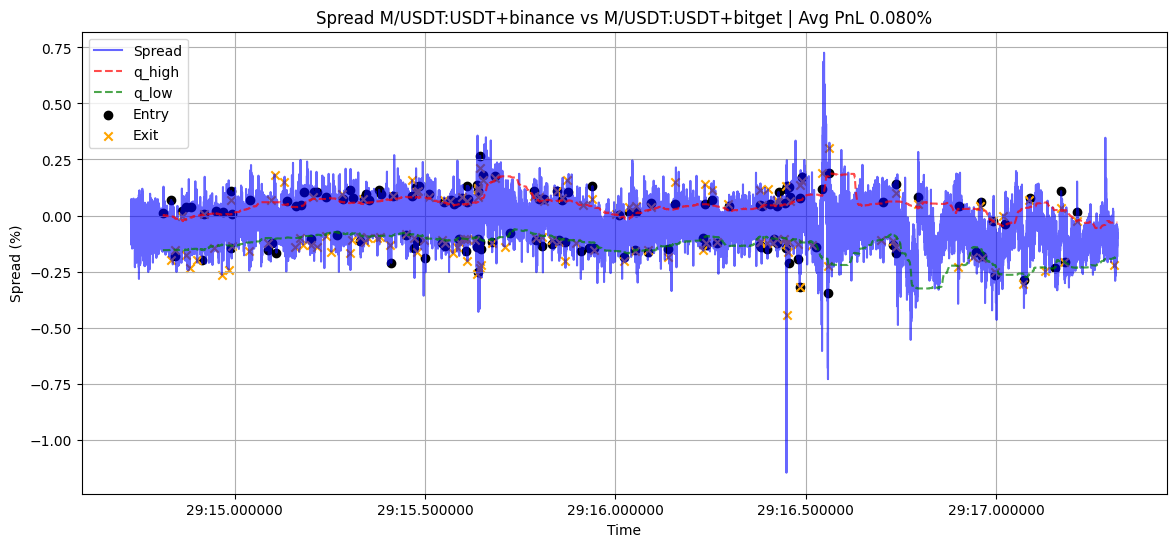

,entry_time,exit_time,position,entry_spread,exit_spread,pnl_pct,cum_pnl_pct
0,1970-01-01 00:29:14.812800,1970-01-01 00:29:14.832780,short_spread,0.010728,-0.196218,0.046947,0.046947
1,1970-01-01 00:29:14.833140,1970-01-01 00:29:14.842440,short_spread,0.069696,-0.154608,0.064304,0.111251
2,1970-01-01 00:29:14.842620,1970-01-01 00:29:14.860680,long_spread,-0.181366,0.000000,0.021366,0.132617
3,1970-01-01 00:29:14.860860,1970-01-01 00:29:14.871180,short_spread,0.022232,-0.174330,0.036562,0.169179
4,1970-01-01 00:29:14.872500,1970-01-01 00:29:14.881500,short_spread,0.036707,-0.233460,0.110166,0.279345
...,...,...,...,...,...,...,...
137,1970-01-01 00:29:17.088060,1970-01-01 00:29:17.129040,short_spread,0.078147,-0.246101,0.164248,10.975610
138,1970-01-01 00:29:17.156340,1970-01-01 00:29:17.170980,long_spread,-0.234742,0.031480,0.106222,11.081832
139,1970-01-01 00:29:17.171160,1970-01-01 00:29:17.179560,short_spread,0.109119,-0.208912,0.158031,11.239863
140,1970-01-01 00:29:17.180040,1970-01-01 00:29:17.212500,long_spread,-0.208586,-0.023526,0.025059,11.264922


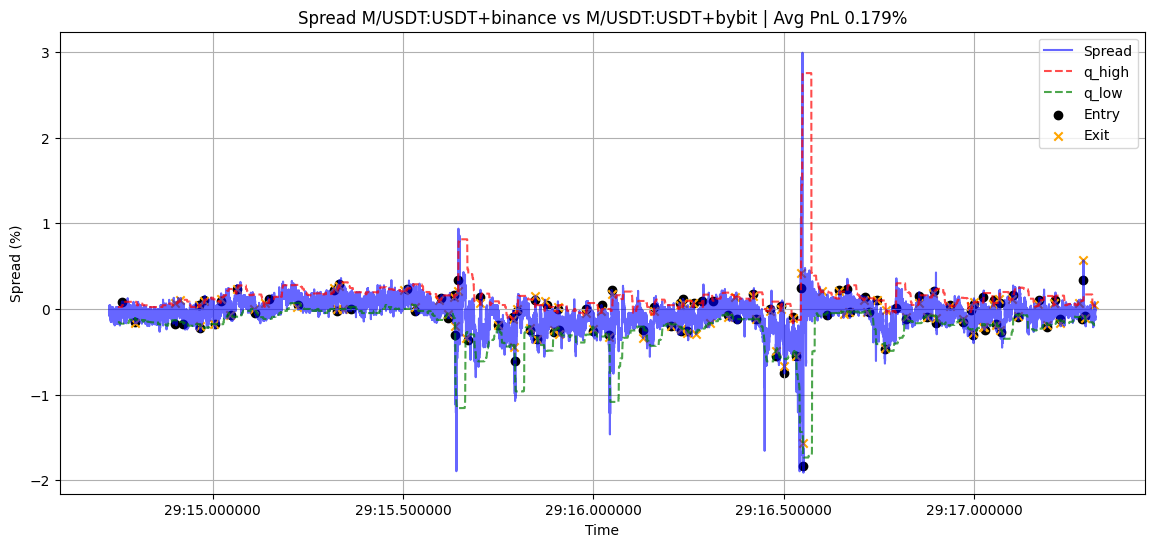

,entry_time,exit_time,position,entry_spread,exit_spread,pnl_pct,cum_pnl_pct
0,1970-01-01 00:29:14.761140,1970-01-01 00:29:14.795940,short_spread,0.084459,-0.168492,0.092951,0.092951
1,1970-01-01 00:29:14.796000,1970-01-01 00:29:14.899320,long_spread,-0.147804,0.065232,0.053036,0.145987
2,1970-01-01 00:29:14.901360,1970-01-01 00:29:14.913840,long_spread,-0.171600,0.106906,0.118506,0.264493
3,1970-01-01 00:29:14.922360,1970-01-01 00:29:14.964300,long_spread,-0.171013,0.044425,0.055438,0.319931
4,1970-01-01 00:29:14.964360,1970-01-01 00:29:14.966100,short_spread,0.044375,-0.198763,0.083139,0.403070
...,...,...,...,...,...,...,...
94,1970-01-01 00:29:17.213040,1970-01-01 00:29:17.226480,short_spread,0.108058,-0.169779,0.117837,16.952990
95,1970-01-01 00:29:17.226540,1970-01-01 00:29:17.276100,long_spread,-0.122340,0.073079,0.035419,16.988409
96,1970-01-01 00:29:17.284740,1970-01-01 00:29:17.287320,long_spread,-0.117540,0.568528,0.526068,17.514477
97,1970-01-01 00:29:17.287380,1970-01-01 00:29:17.290140,short_spread,0.336993,-0.102288,0.279281,17.793758


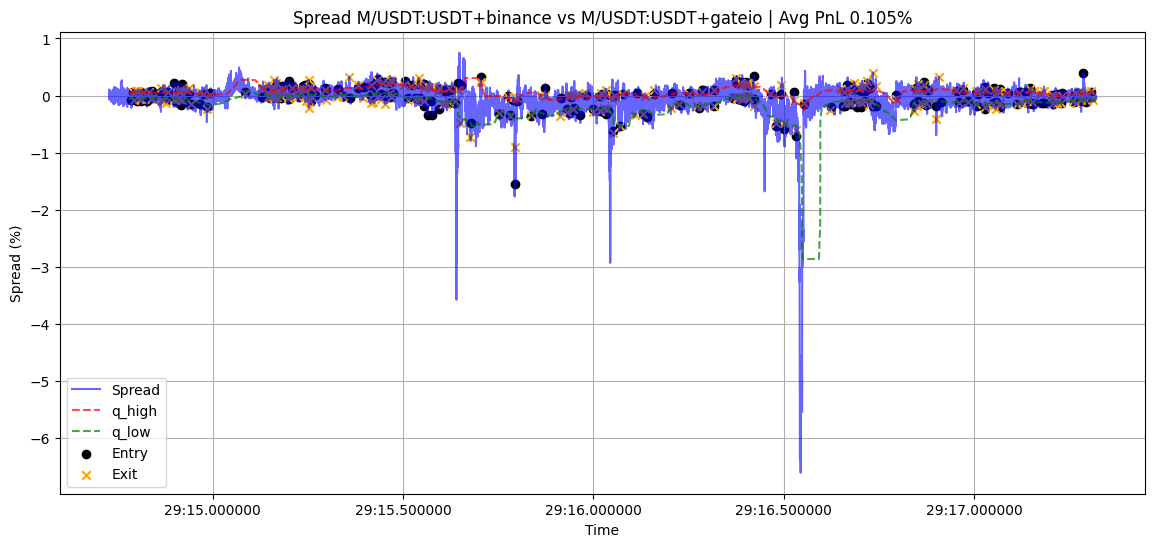

,entry_time,exit_time,position,entry_spread,exit_spread,pnl_pct,cum_pnl_pct
0,1970-01-01 00:29:14.784600,1970-01-01 00:29:14.789160,long_spread,-0.071967,0.062880,-0.025153,-0.025153
1,1970-01-01 00:29:14.791440,1970-01-01 00:29:14.791920,short_spread,0.064733,-0.077120,-0.018147,-0.043300
2,1970-01-01 00:29:14.796300,1970-01-01 00:29:14.798340,long_spread,-0.061247,0.087723,-0.011030,-0.054330
3,1970-01-01 00:29:14.799780,1970-01-01 00:29:14.802180,long_spread,-0.098766,0.080928,0.019694,-0.034635
4,1970-01-01 00:29:14.802240,1970-01-01 00:29:14.806680,short_spread,0.066448,-0.061003,-0.032550,-0.067185
...,...,...,...,...,...,...,...
243,1970-01-01 00:29:17.280420,1970-01-01 00:29:17.287080,long_spread,-0.095544,0.047800,-0.016656,25.690397
244,1970-01-01 00:29:17.287320,1970-01-01 00:29:17.292960,short_spread,0.398309,-0.076306,0.314616,26.005013
245,1970-01-01 00:29:17.293020,1970-01-01 00:29:17.293440,long_spread,-0.106196,0.063314,0.009510,26.014523
246,1970-01-01 00:29:17.296140,1970-01-01 00:29:17.308080,long_spread,-0.100875,0.075565,0.016440,26.030964


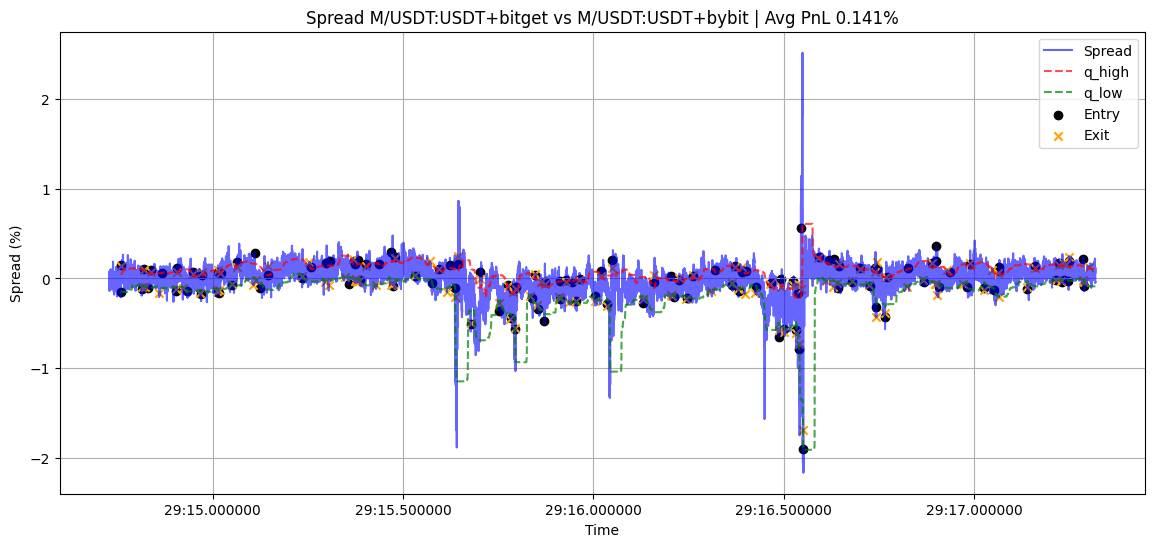

,entry_time,exit_time,position,entry_spread,exit_spread,pnl_pct,cum_pnl_pct
0,1970-01-01 00:29:14.758140,1970-01-01 00:29:14.759520,long_spread,-0.151982,0.137916,0.129898,0.129898
1,1970-01-01 00:29:14.759700,1970-01-01 00:29:14.812620,short_spread,0.147898,-0.096277,0.084175,0.214073
2,1970-01-01 00:29:14.812800,1970-01-01 00:29:14.819040,long_spread,-0.117874,0.093499,0.051373,0.265446
3,1970-01-01 00:29:14.819220,1970-01-01 00:29:14.820660,short_spread,0.100065,-0.091964,0.032029,0.297475
4,1970-01-01 00:29:14.830680,1970-01-01 00:29:14.836380,long_spread,-0.107669,0.067705,0.015373,0.312849
...,...,...,...,...,...,...,...
121,1970-01-01 00:29:17.237160,1970-01-01 00:29:17.241600,long_spread,-0.022969,0.160868,0.023837,17.529458
122,1970-01-01 00:29:17.246700,1970-01-01 00:29:17.249400,long_spread,-0.023723,0.236388,0.100111,17.629569
123,1970-01-01 00:29:17.249580,1970-01-01 00:29:17.287020,short_spread,0.189639,-0.012888,0.042527,17.672096
124,1970-01-01 00:29:17.287320,1970-01-01 00:29:17.287620,short_spread,0.220812,-0.035820,0.096632,17.768728


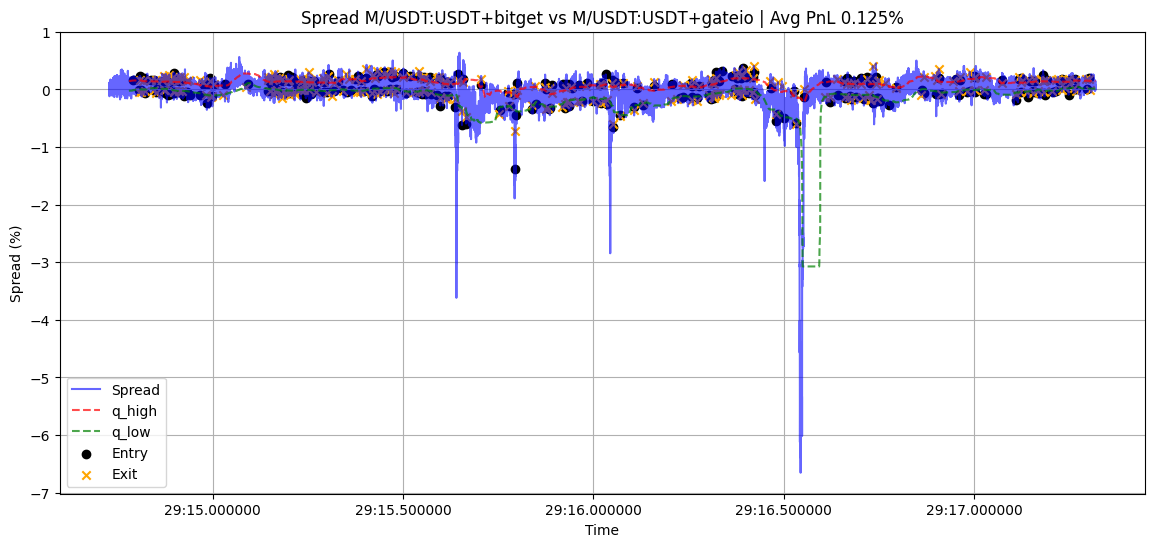

,entry_time,exit_time,position,entry_spread,exit_spread,pnl_pct,cum_pnl_pct
0,1970-01-01 00:29:14.789100,1970-01-01 00:29:14.806740,short_spread,0.171811,-0.046252,0.058063,0.058063
1,1970-01-01 00:29:14.806800,1970-01-01 00:29:14.808360,long_spread,-0.010540,0.171208,0.021748,0.079811
2,1970-01-01 00:29:14.808420,1970-01-01 00:29:14.811840,short_spread,0.235454,-0.045356,0.120810,0.200621
3,1970-01-01 00:29:14.811900,1970-01-01 00:29:14.817540,long_spread,-0.002154,0.153636,-0.004209,0.196412
4,1970-01-01 00:29:14.818200,1970-01-01 00:29:14.820660,short_spread,0.201220,-0.035054,0.076274,0.272686
...,...,...,...,...,...,...,...
273,1970-01-01 00:29:17.264340,1970-01-01 00:29:17.264880,long_spread,0.004719,0.161878,-0.002841,34.689680
274,1970-01-01 00:29:17.264940,1970-01-01 00:29:17.267640,short_spread,0.184686,-0.032653,0.057340,34.747019
275,1970-01-01 00:29:17.267700,1970-01-01 00:29:17.293260,long_spread,0.014257,0.174306,0.000049,34.747068
276,1970-01-01 00:29:17.296140,1970-01-01 00:29:17.301900,long_spread,0.012609,0.180288,0.007679,34.754747


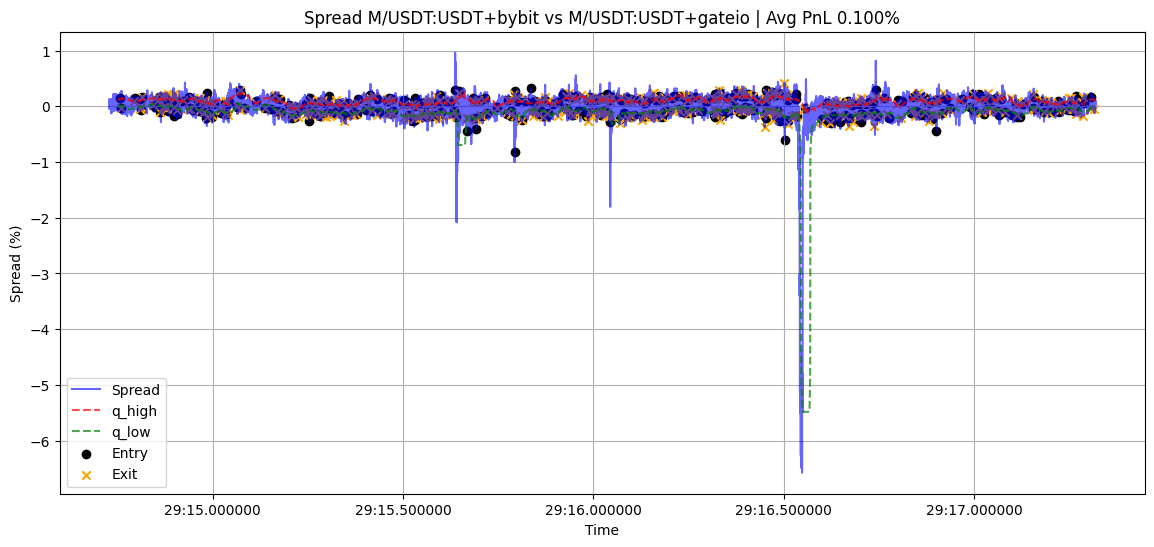

,entry_time,exit_time,position,entry_spread,exit_spread,pnl_pct,cum_pnl_pct
0,1970-01-01 00:29:14.755200,1970-01-01 00:29:14.758920,short_spread,0.151379,-0.031932,0.023311,0.023311
1,1970-01-01 00:29:14.759340,1970-01-01 00:29:14.793780,long_spread,-0.029842,0.089870,-0.040288,-0.016978
2,1970-01-01 00:29:14.795640,1970-01-01 00:29:14.808900,short_spread,0.155639,-0.053017,0.048655,0.031678
3,1970-01-01 00:29:14.809320,1970-01-01 00:29:14.811840,short_spread,0.130512,-0.021598,-0.007890,0.023788
4,1970-01-01 00:29:14.811900,1970-01-01 00:29:14.812680,long_spread,-0.075407,0.160582,0.075989,0.099777
...,...,...,...,...,...,...,...
396,1970-01-01 00:29:17.266740,1970-01-01 00:29:17.267640,short_spread,0.186782,-0.139566,0.166347,39.877944
397,1970-01-01 00:29:17.267700,1970-01-01 00:29:17.286960,long_spread,-0.064420,0.158623,0.063044,39.940987
398,1970-01-01 00:29:17.287020,1970-01-01 00:29:17.287320,short_spread,0.087608,-0.169256,0.096864,40.037851
399,1970-01-01 00:29:17.287620,1970-01-01 00:29:17.304540,short_spread,0.058882,-0.040833,-0.060285,39.977566


In [ ]:
pairs = [
    ("M/USDT:USDT+binance", "M/USDT:USDT+bitget"),
    ("M/USDT:USDT+binance", "M/USDT:USDT+bybit"),
    ("M/USDT:USDT+binance", "M/USDT:USDT+gateio"),
    ("M/USDT:USDT+bitget", "M/USDT:USDT+bybit"),
    ("M/USDT:USDT+bitget", "M/USDT:USDT+gateio"),
    ("M/USDT:USDT+bybit", "M/USDT:USDT+gateio"),
]

results = {}
for exch1, exch2 in pairs:
    params = pair_params.get((exch1, exch2), None)  # use optimal if available, else defaults
    trades_df = backtest_and_plot(df, exch1, exch2, params=params, plot=True)
    if trades_df is not None:
        results[(exch1, exch2)] = trades_df
        display(trades_df)
